# 🔬 구현 과제 2 — Micrograd: 자동미분 엔진 직접 구현

> **Phase 0 — 수학 & Python 기초** | 구현 과제 2 / 3

---

## 이 노트북에서 만드는 것

PyTorch의 `.backward()` 가 내부적으로 하는 일을 **직접** 구현합니다.
연쇄법칙이 코드로 어떻게 표현되는지 한 줄씩 확인합니다.

```
배운 것 (수식)           →   만드는 것 (코드)
────────────────────────────────────────────
∂f/∂x = ∂f/∂u × ∂u/∂x  →  Value._backward()
계산 그래프              →  Value._prev
오른쪽→왼쪽 순회         →  topological_sort() + reversed()
```

## 학습 목표
- [ ] `Value` 클래스로 계산 그래프 자동 구축
- [ ] 덧셈·곱셈·거듭제곱·ReLU·tanh 의 `_backward` 직접 구현
- [ ] 위상 정렬(topological sort)로 역전파 순서 결정
- [ ] PyTorch 결과와 비교 검증
- [ ] 직접 만든 엔진으로 MLP 학습 (XOR 문제)
- [ ] wandb로 학습 곡선 기록

## 0. 환경 설정

In [1]:
!pip install wandb -q

import math, random, wandb
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)
print('환경 설정 완료 ✓')

환경 설정 완료 ✓


In [2]:
wandb.login()

run = wandb.init(
    project='portfolio-tsuruoka-lab',
    name='phase0-02-micrograd',
    tags=['phase0', 'autograd', 'backprop', 'from-scratch'],
    config={'phase': 0, 'assignment': 2, 'topic': 'autograd-engine'}
)
print(f'wandb run: {run.url}')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: swsw778 (swsw778-korea-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb run: https://wandb.ai/swsw778-korea-university/portfolio-tsuruoka-lab/runs/pim8m633


---
## 1. Value 클래스 — 계산 그래프의 한 노드

모든 숫자를 `Value` 객체로 감쌉니다. 연산할 때마다 **어떤 연산으로 만들어졌는지** 자동으로 기록됩니다.

```
a = Value(2.0)   →   노드: data=2.0, _op=''
b = Value(3.0)   →   노드: data=3.0, _op=''
c = a + b        →   노드: data=5.0, _op='+', _prev={a, b}
                                               ↑
                               '나는 a와 b를 더해서 만들어졌다'
```

In [3]:
class Value:
    """
    자동미분을 지원하는 스칼라 값.
    PyTorch의 Tensor (스칼라 버전)와 동일한 역할.
    """
    def __init__(self, data, _children=(), _op='', label=''):
        self.data      = float(data)    # 순전파 값
        self.grad      = 0.0            # 역전파 그래디언트 (초기값 0)
        self._op       = _op            # 이 노드를 만든 연산
        self._prev     = set(_children) # 입력 노드들
        self.label     = label
        self._backward = lambda: None   # 기본: 아무것도 안 함 (리프 노드)

    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'


a = Value(2.0, label='a')
b = Value(3.0, label='b')
print(a)
print(f'a.grad 초기값: {a.grad}  ← 역전파 전에는 항상 0')

Value(data=2.0000, grad=0.0000)
a.grad 초기값: 0.0  ← 역전파 전에는 항상 0


---
## 2. 연산 구현 — 각 연산마다 _backward 정의

### 핵심 원리
```
순전파:  c = a + b          →  c.data = a.data + b.data
역전파:  a.grad += c.grad   ←  ∂c/∂a = 1  (덧셈 노드: 그대로 통과)
         b.grad += c.grad   ←  ∂c/∂b = 1
```
**왜 `+=` 인가?** 같은 노드가 여러 곳에서 사용되면 그래디언트가 **합산**됩니다.

In [4]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data      = float(data)
        self.grad      = 0.0
        self._op       = _op
        self._prev     = set(_children)
        self.label     = label
        self._backward = lambda: None

    # ── 덧셈 ────────────────────────────────────────────────────────
    # 수식: c = a + b
    # 역전파: ∂c/∂a = 1, ∂c/∂b = 1  →  상류 grad 그대로 통과
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += out.grad   # 1 × out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    # ── 곱셈 ────────────────────────────────────────────────────────
    # 수식: c = a * b
    # 역전파: ∂c/∂a = b, ∂c/∂b = a  →  서로 값을 바꿔서 곱함
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad  # ← 상대방 값을 곱함!
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    # ── 거듭제곱 ─────────────────────────────────────────────────────
    # 수식: out = self^n
    # 역전파: n * self^(n-1)  →  고전적인 미분 공식 그대로
    def __pow__(self, n):
        assert isinstance(n, (int, float))
        out = Value(self.data ** n, (self,), f'**{n}')
        def _backward():
            self.grad += (n * self.data**(n-1)) * out.grad
        out._backward = _backward
        return out

    # ── ReLU ─────────────────────────────────────────────────────────
    # 역전파: 양수면 통과(1), 음수면 차단(0)  ← 퀴즈 2번 내용!
    def relu(self):
        out = Value(max(0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    # ── tanh ─────────────────────────────────────────────────────────
    # 역전파: 1 - tanh²(x)
    def tanh(self):
        t   = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    # ── 편의 메서드 ──────────────────────────────────────────────────
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __neg__(self):         return self * -1
    def __sub__(self, other):  return self + (-other)
    def __truediv__(self, other): return self * other**-1
    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'


print('Value 클래스 정의 완료 ✓')
a = Value(3.0)
b = Value(4.0)
c = a * b
print(f'3 * 4 = {c}')
print(f'c._prev = {c._prev}')
print(f"c._op   = '{c._op}'")

Value 클래스 정의 완료 ✓
3 * 4 = Value(data=12.0000, grad=0.0000)
c._prev = {Value(data=3.0000, grad=0.0000), Value(data=4.0000, grad=0.0000)}
c._op   = '*'


---
## 3. backward() — 연쇄법칙을 그래프 위에서 실행

역전파는 두 단계입니다:
1. **위상 정렬**: 노드를 '입력 먼저' 순서로 정렬
2. **역순 순회**: 뒤집어서 `_backward()` 호출

```
계산 그래프:  x → [**2] → u → [+3] → v → [*2] → L
위상 정렬:    x, u, v, L
역전파 순서:  L, v, u, x  (reversed)
```

In [5]:
def backward(root):
    """root에서 시작해 역전파 실행. = loss.backward()"""

    # Step 1: 위상 정렬 (DFS)
    topo, visited = [], set()
    def build_topo(node):
        if node not in visited:
            visited.add(node)
            for child in node._prev:
                build_topo(child)
            topo.append(node)  # 자신은 자식 처리 후에 추가
    build_topo(root)

    # Step 2: 출발 grad = 1  (∂L/∂L = 1)
    root.grad = 1.0

    # Step 3: 역순으로 _backward() 호출
    for node in reversed(topo):
        node._backward()

    return topo


# ── 검증: f(x) = (3x + 1)² , x = 2 ──────────────────────────────────
# 손으로 계산: f'(2) = 2(3*2+1)*3 = 42
x = Value(2.0, label='x')
u = x * 3 + 1
f = u ** 2
u.label = 'u'; f.label = 'f'

topo = backward(f)

print('순전파:  x=2, u=3x+1=7, f=u²=49')
print(f'역전파:  x.grad = {x.grad}  ← 기대값: 42 ✓' if abs(x.grad-42)<1e-9 else f'x.grad={x.grad} 오류')
print(f'         u.grad = {u.grad}  ← 기대값: 14 ✓' if abs(u.grad-14)<1e-9 else f'u.grad={u.grad} 오류')
print()
print('위상 정렬:', [n.label or n._op or f'{n.data:.1f}' for n in topo])

순전파:  x=2, u=3x+1=7, f=u²=49
역전파:  x.grad = 42.0  ← 기대값: 42 ✓
         u.grad = 14.0  ← 기대값: 14 ✓

위상 정렬: ['1.0', '3.0', 'x', '*', 'u', 'f']


---
## 4. PyTorch와 결과 비교 검증

직접 만든 엔진이 PyTorch와 동일한 결과를 내는지 확인합니다.

In [6]:
import torch

def verify(name, mg_vals, mg_fn, pt_vals, pt_fn):
    mg_out = mg_fn(*mg_vals)
    backward(mg_out)
    pt_out = pt_fn(*pt_vals)
    pt_out.backward()
    print(f'\n── {name} ──')
    for i, (m, p) in enumerate(zip(mg_vals, pt_vals)):
        mg_g, pt_g = m.grad, p.grad.item()
        ok = abs(mg_g - pt_g) < 1e-5
        print(f'  입력{i}: micrograd={mg_g:.5f}  PyTorch={pt_g:.5f}  {"✓" if ok else "✗"}')


# 케이스 1: f = (a+b)*c
verify('f = (a+b)*c',
    [Value(2.), Value(-3.), Value(10.)],
    lambda a,b,c: (a+b)*c,
    [torch.tensor(2.,requires_grad=True), torch.tensor(-3.,requires_grad=True), torch.tensor(10.,requires_grad=True)],
    lambda a,b,c: (a+b)*c,
)

# 케이스 2: f = a**2 + b**3
verify('f = a**2 + b**3',
    [Value(3.), Value(2.)],
    lambda a,b: a**2 + b**3,
    [torch.tensor(3.,requires_grad=True), torch.tensor(2.,requires_grad=True)],
    lambda a,b: a**2 + b**3,
)

# 케이스 3: f = ReLU(a*b + c)
verify('f = ReLU(a*b + c)',
    [Value(-1.), Value(2.), Value(3.)],
    lambda a,b,c: (a*b+c).relu(),
    [torch.tensor(-1.,requires_grad=True), torch.tensor(2.,requires_grad=True), torch.tensor(3.,requires_grad=True)],
    lambda a,b,c: torch.relu(a*b+c),
)

print('\n모든 검증 완료 ✓  micrograd == PyTorch')
wandb.log({'verify/all_passed': True})


── f = (a+b)*c ──
  입력0: micrograd=10.00000  PyTorch=10.00000  ✓
  입력1: micrograd=10.00000  PyTorch=10.00000  ✓
  입력2: micrograd=-1.00000  PyTorch=-1.00000  ✓

── f = a**2 + b**3 ──
  입력0: micrograd=6.00000  PyTorch=6.00000  ✓
  입력1: micrograd=12.00000  PyTorch=12.00000  ✓

── f = ReLU(a*b + c) ──
  입력0: micrograd=2.00000  PyTorch=2.00000  ✓
  입력1: micrograd=-1.00000  PyTorch=-1.00000  ✓
  입력2: micrograd=1.00000  PyTorch=1.00000  ✓

모든 검증 완료 ✓  micrograd == PyTorch


---
## 5. 신경망 구현 — Neuron, Layer, MLP

Value 엔진 위에 신경망을 쌓습니다. 모든 가중치가 Value이므로 자동미분이 그대로 작동합니다.

In [7]:
class Neuron:
    """단일 뉴런: y = activation(w·x + b)"""
    def __init__(self, n_inputs, activation='relu'):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.b = Value(0.0)
        self.activation = activation

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        if self.activation == 'relu':   return act.relu()
        if self.activation == 'tanh':   return act.tanh()
        return act

    def parameters(self): return self.w + [self.b]


class Layer:
    def __init__(self, n_in, n_out, activation='relu'):
        self.neurons = [Neuron(n_in, activation) for _ in range(n_out)]
    def __call__(self, x):    return [n(x) for n in self.neurons]
    def parameters(self):     return [p for n in self.neurons for p in n.parameters()]


class MLP:
    """다층 퍼셉트론. MLP(2,[4,4,1]) = 2→4→4→1"""
    def __init__(self, n_inputs, layer_sizes):
        sizes = [n_inputs] + layer_sizes
        self.layers = [
            Layer(sizes[i], sizes[i+1],
                  activation='relu' if i < len(layer_sizes)-1 else 'linear')
            for i in range(len(layer_sizes))
        ]

    def __call__(self, x):
        for layer in self.layers: x = layer(x)
        return x[0] if len(x)==1 else x

    def parameters(self):  return [p for l in self.layers for p in l.parameters()]
    def zero_grad(self):   
        for p in self.parameters(): p.grad = 0.0


model = MLP(2, [8, 8, 1])
print(f'MLP(2→8→8→1) | 파라미터 수: {len(model.parameters())}')
# 테스트 순전파
out = model([0.5, 0.3])
print(f'테스트 순전파: {out}')

MLP(2→8→8→1) | 파라미터 수: 105
테스트 순전파: Value(data=0.0000, grad=0.0000)


---
## 6. 학습 — XOR 문제

선형 분리 불가능한 XOR을 MLP로 풀면서 자동미분 엔진을 검증합니다.

In [8]:
X_xor = [[0.,0.],[0.,1.],[1.,0.],[1.,1.]]
y_xor = [-1., 1., 1., -1.]  # hinge loss용 -1/+1 레이블

random.seed(42)
model = MLP(2, [8, 8, 1])
lr, n_epochs = 0.05, 200

wandb.config.update({'lr':lr,'epochs':n_epochs,'arch':'2-8-8-1','problem':'XOR'})

losses, accs = [], []

for epoch in range(n_epochs):
    preds = [model(x) for x in X_xor]

    # Hinge Loss: sum( max(0, 1 - y*ŷ) )
    data_loss = sum((Value(1.) + Value(-yi)*pi).relu() for pi, yi in zip(preds, y_xor))
    reg_loss  = Value(1e-4) * sum(p**2 for p in model.parameters())
    loss      = data_loss + reg_loss

    model.zero_grad()   # ← optimizer.zero_grad() 와 동일
    backward(loss)      # ← loss.backward() 와 동일

    for p in model.parameters():
        p.data -= lr * p.grad   # ← SGD: w = w - lr * grad

    acc = sum(1 for p,y in zip(preds,y_xor) if (p.data>0)==(y>0)) / len(y_xor)
    losses.append(loss.data); accs.append(acc)
    wandb.log({'train/loss':loss.data, 'train/accuracy':acc}, step=epoch)

    if epoch % 40 == 0:
        print(f'Epoch {epoch:4d} | loss: {loss.data:.4f} | acc: {acc*100:.0f}%')

print(f'\n최종 loss: {losses[-1]:.4f} | 최종 acc: {accs[-1]*100:.0f}%')

Epoch    0 | loss: 4.0064 | acc: 75%
Epoch   40 | loss: 1.5073 | acc: 75%
Epoch   80 | loss: 0.2541 | acc: 100%
Epoch  120 | loss: 0.0044 | acc: 100%
Epoch  160 | loss: 0.0044 | acc: 100%

최종 loss: 0.0044 | 최종 acc: 100%


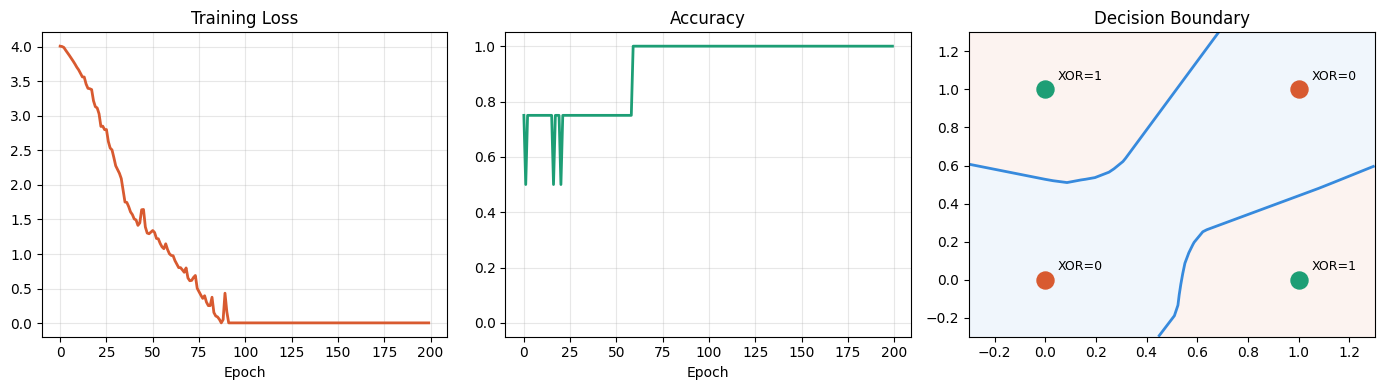

시각화 wandb 업로드 완료 ✓


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(losses, color='#D85A30', linewidth=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=.3)

axes[1].plot(accs, color='#1D9E75', linewidth=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(-0.05, 1.05); axes[1].grid(alpha=.3)

res = 30
xx, yy = np.meshgrid(np.linspace(-.3,1.3,res), np.linspace(-.3,1.3,res))
Z = np.array([model([float(x),float(y)]).data
              for x,y in zip(xx.ravel(),yy.ravel())]).reshape(xx.shape)
axes[2].contourf(xx,yy,Z,levels=[-999,0,999],colors=['#E6F1FB','#FAECE7'],alpha=.6)
axes[2].contour(xx,yy,Z,levels=[0],colors=['#378ADD'],linewidths=2)
colors = ['#D85A30' if y<0 else '#1D9E75' for y in y_xor]
labels_t = ['XOR=0','XOR=1','XOR=1','XOR=0']
for (xi, yi_), col, lbl in zip(X_xor, colors, labels_t):
    axes[2].scatter(xi, yi_, c=col, s=150, zorder=5)           
    axes[2].annotate(lbl, (xi + .05, yi_ + .05), fontsize=9)   
axes[2].set_title('Decision Boundary')

plt.tight_layout()
wandb.log({'results/training_curves': wandb.Image(fig)})
plt.savefig('micrograd_xor_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('시각화 wandb 업로드 완료 ✓')

In [11]:
print('='*58)
print('Week 2 핵심: 수식 → 코드 매핑')
print('='*58)
rows = [
    ('∂f/∂x = ∂f/∂u × ∂u/∂x',     '_backward() 내부의 += 계산'),
    ('덧셈: 그래디언트 그대로 통과', 'self.grad += out.grad'),
    ('곱셈: 상대방 값 곱해서 통과',  'self.grad += other.data * out.grad'),
    ('ReLU: 음수면 grad 0',          '(out.data > 0) * out.grad'),
    ('역전파 순서 결정',              'topological_sort() + reversed()'),
    ('∂L/∂L = 1',                    'root.grad = 1.0'),
    ('w ← w - lr × ∂L/∂w',          'p.data -= lr * p.grad'),
]
for m, c in rows: print(f'  {m:<36} → {c}')

wandb.summary.update({
    'final_loss': losses[-1], 'final_accuracy': accs[-1],
    'total_params': len(model.parameters()),
    'verify_passed': True, 'xor_solved': accs[-1]==1.0,
})
wandb.finish()
print('\nwandb run 완료 ✓')

Week 2 핵심: 수식 → 코드 매핑
  ∂f/∂x = ∂f/∂u × ∂u/∂x                → _backward() 내부의 += 계산
  덧셈: 그래디언트 그대로 통과                     → self.grad += out.grad
  곱셈: 상대방 값 곱해서 통과                     → self.grad += other.data * out.grad
  ReLU: 음수면 grad 0                     → (out.data > 0) * out.grad
  역전파 순서 결정                            → topological_sort() + reversed()
  ∂L/∂L = 1                            → root.grad = 1.0
  w ← w - lr × ∂L/∂w                   → p.data -= lr * p.grad


train/accuracy,▁▁▁▁▁▁▁▁▁▁██████████████████████████████
train/loss,█▇▆▆▆▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_accuracy,1
final_loss,0.00439
total_params,105
train/accuracy,1
train/loss,0.00439
verify/all_passed,True
verify_passed,True
xor_solved,True



wandb run 완료 ✓


---
## 7. 체크리스트 & 다음 단계

### 완료 확인
- [ ] `Value` + `_backward` 구현
- [ ] `backward()` — 위상 정렬 + 역순 순회
- [ ] PyTorch 비교 검증 3케이스 통과
- [ ] MLP XOR 100% 정확도
- [ ] wandb 학습 곡선 + 결정 경계 업로드
- [ ] GitHub commit

### Commit 메시지
```
phase0/02: implement autograd engine from scratch

- Value class: add/mul/pow/relu/tanh with _backward
- backward(): topological sort + reverse traversal  
- verified: micrograd == pytorch on 3 test cases
- MLP trained on XOR: 100% accuracy in 200 epochs
- wandb: loss curve + decision boundary logged
```

### 이 과제 → 나중에 연결되는 곳
| 오늘 만든 것 | Phase 1+에서 만나는 곳 |
|---|---|
| `Value._backward` | PyTorch Autograd 내부 구조 |
| `backward()` 위상 정렬 | `loss.backward()` 실제 동작 |
| `Neuron.__call__` | `nn.Linear` 순전파 |
| `model.zero_grad()` | `optimizer.zero_grad()` |
| `p.data -= lr * p.grad` | `optimizer.step()` (SGD) |

### 다음 과제
**[→ 구현 과제 3: MLP MNIST — NumPy → PyTorch → Lightning](../03-mlp-mnist/)**